# Time series of stress in Tom's Creek

This is a notebook that takes the raw HOBO depth logger data, measured cross sections, and dates of observations and transforms the depth measurements into estimates of stress. These stress time series are then compared to potential thresholds for the onset of nest stone movement. Points in time where observations were made of nest stability are marked. 

## Imports and functions used in the analysis

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os

%config InlineBackend.figure_format='retina' 

In [2]:
# -----------------------------------------------------
# Functions for filtering raw HOBO data
# ------------------------------------------------------

# returns the clear-water density in kg/m^3 as a function of temperature [in deg C] and salinity [ppt]
def rho_cw(T,S): 
    rho_fresh=1000*(1-(T +288.9414)/(508929.2*(T+68.12963))*(T-3.9863)**2)
    Acoef = 0.824493 - 0.0040899*T + 0.000076438*T**2 -0.00000082467*T**3 + 0.0000000053675*T**4
    Bcoef = -0.005724 + 0.00010227*T - 0.0000016546*T**2
    return rho_fresh + Acoef*S + Bcoef*S**(3/2) + 0.00048314*S**2 

def find_roots(x,y): # finds where water surface intersects banks (terrain survey)
    # when you need to interpolate to find the x val:
    s_interp = (np.abs(np.diff(np.sign(y))) == 2).astype(bool) 
    # == 1 would include points that just meet WSE, so use ==2 to ensure pairs of bank stations
    # when the WSE is an exact survey point, pick first and/or last time difference of sign is 1 (-1 to 0 or 1 to 0):
    if np.sum(s_interp) < 2: # would not work if more than 2 bank points (i.e., forked channel)
        s_deadon = []
        # find the index of the second 1 in each pair of 1's, indicating index of bank deadon in y array:
        for i_diff in range(1, len(np.abs(np.diff(np.sign(y))))):
            if np.abs(np.diff(np.sign(y)))[i_diff] == 1 and np.abs(np.diff(np.sign(y)))[i_diff - 1] == 1:
                s_deadon.append(i_diff)
        
        x_interp = x[:-1][s_interp] + np.diff(x)[s_interp]/(np.abs(y[1:][s_interp]/y[:-1][s_interp])+1)
        if len(s_deadon) ==1:
            x_deadon = np.array([x[s_deadon]]).flatten()
        else:
            x_deadon = x[s_deadon].flatten()
        roots = sorted(np.concatenate((x_interp, x_deadon)))
    else:
        roots = x[:-1][s_interp] + np.diff(x)[s_interp]/(np.abs(y[1:][s_interp]/y[:-1][s_interp])+1)              
    return roots

def wet_perimeter(x,y):
    n = len(x)
    P = 0.0

    for i in range(n-2): # minus 2 to not include WS
        dx = x[i+1] - x[i]
        dy = y[i+1] - y[i]
        P += np.sqrt(dx**2 + dy**2)

    return P

def shoelace_area(x, y):
    n = len(x)
    A = 0.0

    # Shoelace formula
    for i in range(n - 1):
        A += x[i] * y[i + 1] - x[i + 1] * y[i]

    # last edge connecting first and last vertices
    A += x[n - 1] * y[0] - x[0] * y[n - 1]

    # Take the absolute value and divide by 2
    A = abs(A)/2

    return A

def xsgeo_solver(depth,xsurvey,ysurvey,INTERP,N,SHOELACE):
    # Sort xsurvey and ysurvey by xsurvey
    sorted_indices = np.argsort(xsurvey)
    xsurvey = xsurvey[sorted_indices]
    ysurvey = ysurvey[sorted_indices]

    ycrit = np.min([ysurvey[0],ysurvey[-1]])

    # Initialize return values
    A = np.nan
    Pw = np.nan
    Rh = np.nan

    if np.isnan(depth):
        return A, Pw, Rh

    else:
        if depth > ycrit: # increases the height of the sides if the water is higher than the survey points
            xsurvey = np.concatenate([[xsurvey[0]],xsurvey,[xsurvey[-1]]])
            ysurvey = np.concatenate([[ysurvey[0]+2*(depth-ycrit)],ysurvey,[ysurvey[-1]+2*(depth-ycrit)]])

        # interpolate
        if INTERP == 'yes':
            x_1 = np.linspace(xsurvey.min(),xsurvey.max(),N)
            y_1 = np.interp(x_1, xsurvey, ysurvey)
        else:
            x_1 = xsurvey
            y_1 = ysurvey
        
        if depth != 0.0:
            ## find the x locations of the flow top width (interpolates between points)
            roots = find_roots(x_1,y_1-depth)
            bank_sta_pairs = []
            for i in range(0, len(roots), 2):
                pair = [roots[i], roots[i + 1]]
                bank_sta_pairs.append(pair)


            A_arr = []
            Pw_arr = []
            for pair in range(len(bank_sta_pairs)):
                
                xbank = bank_sta_pairs[pair]
                
                subset_indices_mid = np.where((x_1 >= xbank[0]) & (x_1 <= xbank[1]))[0]
                if len(subset_indices_mid) == 0:
                    continue
                start_i = max(0, subset_indices_mid[0]-1)
                end_i = min(len(x_1), subset_indices_mid[-1]+2)
                subset_indices = np.arange(start_i, end_i)
                
                x_subset = x_1[subset_indices]
                y_subset = y_1[subset_indices]
                
                x_2 = x_subset
                y_2 = y_subset

                ## find the paired depths and x values
                h_all = depth - y_2
                h_wet = np.concatenate([[0],h_all[(h_all>0)],[0]])
                x_wet = np.concatenate([[xbank[0]],x_2[(h_all>0)],[xbank[-1]]])

                # calculate wetted cross section ---
                if SHOELACE == 'yes':
                    ## segmented wetted perimeter, not including WS
                    P_i = wet_perimeter(x_wet,h_wet)
                    ## shoelace flow area
                    A_i = shoelace_area(x_wet,h_wet)
                else:
                    ## calculate wetted perimeter
                    dx=x_wet[1:]-x_wet[0:-1]
                    dh=h_wet[1:]-h_wet[0:-1]
                    pi=np.sqrt(dx**2 + dh**2)
                    P_i = np.sum(pi)
                    ## calculate flow area
                    ai = 0.5*dx*(h_wet[0:-1]+h_wet[1:])
                    A_i = np.sum(ai)
                
                A_arr.append(A_i)
                Pw_arr.append(P_i)
            if A_arr and Pw_arr:
                A = sum(A_arr)
                Pw = sum(Pw_arr)
                Rh = A / Pw if Pw != 0 else np.nan
            else:
                A = Pw = Rh = 0.0
        else:
            A = Pw = Rh = 0.0

    return A,Pw,Rh

# ------------------------------------------------------
# Functions for plotting the stress time series
# ------------------------------------------------------

def plot_stress_timeseries(df, checks_df, datetime_col, stress_col, nest_name, save_suffix):
    # Plot a Shields-stress time series with the critical-stress thresholds and
    # measurement-time markers, save it to fig_folder, and return the axes so a
    # standalone legend can be exported afterward. Styling constants (width, height,
    # linewidth, thresholds, etc.) are taken from the global user-input cells.
    fig, ax = plt.subplots(figsize=(width,height))
    # Plot thresholds
    plt.axhline(y = tau_st_cr_a_brownlie, color='red',alpha=0.6, linewidth=linewidth, linestyle='--', label=r'$\tau^*_{c,a}$ Brownlie (1981)')
    plt.axhline(y = tau_st_cr_a_recking, color='mediumseagreen',alpha=0.6, linewidth=linewidth,linestyle='-.', label=r'$\tau^*_{c,a}$ Recking (2010)')
    # Plot main line
    ax.plot(df[datetime_col], df[stress_col], label='Shields Stress')
    # Plot markers at check points
    ax.plot(checks_df[datetime_col], checks_df[stress_col], 'o', alpha=0.6, color='gray', label='Measurement Times')
    # Labels and formatting
    ax.set_xlabel(r'Date and Time')
    ax.set_ylabel(r'Ambient Shields, $\tau^*_{amb}$ [-]')
    plt.xticks(rotation=45, ha='right')
    plt.savefig(fig_folder+'/'+nest_name+save_suffix, bbox_inches='tight', pad_inches=pad_inches)
    plt.show()
    return ax

def save_legend(ax, nest_name):
    # Export the legend from a completed plot as a standalone PDF.
    handles, labels = ax.get_legend_handles_labels()
    fig_legend, ax_legend = plt.subplots(figsize=(width, height_legend))  # adjust size as needed
    ax_legend.legend(handles, labels, loc='center', ncol=len(labels), frameon=True)
    ax_legend.axis('off')  # hide the axes
    fig_legend.savefig(fig_folder+'/'+nest_name + '_legend.pdf', bbox_inches='tight', pad_inches=pad_inches)
    plt.close(fig_legend)

## Global user input needed

In [3]:
# User Input -----------------------------------------

# paths
datadir_input = 'data_input/' # path to the data
datadir_output = 'data_output/field_timeseries/' # path to the data
fig_folder = 'figures/field_timeseries/'

# params for paper plots:
matplotlib.rcParams.update({'font.size': 7}) # 7 for halfwidth
width = 3
height = 2.25
linewidth = 1
markersize = 10
height_legend = 0.05
pad_inches=0.05

## Field time series plots

### Starting with the raw HOBO data all the way to the final plot

Uses the data found in the files `*_HOBOdata.csv` and `BakerLab*.xlsx` and `SyntheticNests*.xlsx`.

User input is needed to select the time-period and nest to examine. This is done by changing the `nest_num` variable below

min time =  2024-02-08 16:41:54 max time =  2024-04-10 09:46:28
hydraulic radius:


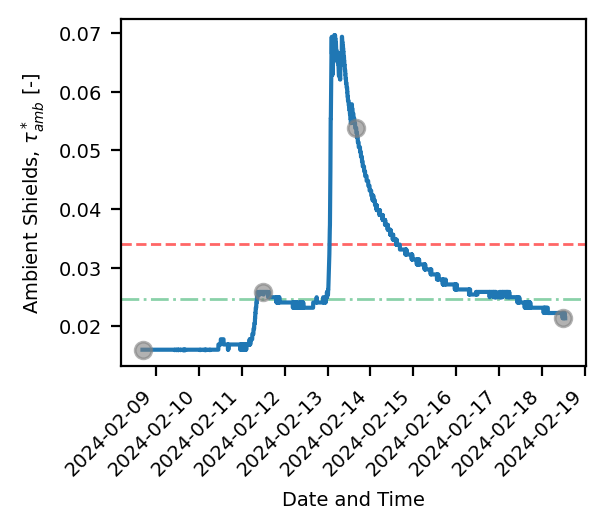

max shields stress from Rh, tau_st =  0.0696316781907257
max shields stress time =  2024-02-13 04:11:54
depth:


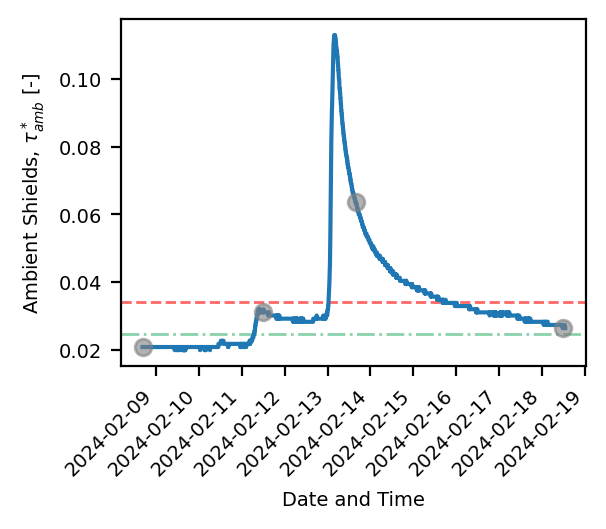

In [4]:
# User input ---------------------------------------------
nest_num = '1' # '1', '2', '3', '4', '5and6'
write_files = 'yes' # 'yes' to write data in figures to csv. 'no' to bypass.
# -------------------------------------------------------

# Make the output folders
if not os.path.isdir(fig_folder):
    os.mkdir(fig_folder)
if not os.path.isdir(datadir_output):
    os.mkdir(datadir_output)

nest_name = 'SynthNest'+nest_num
filepath_main = datadir_input
filepath_hoboDL = filepath_main
XS_excel_sheet = 'XS_csv'

# critical Shields stress thresholds from stress analysis:
tau_st_cr_a_brownlie =  0.03401074441550105
tau_st_cr_a_recking =  0.024734146341463415

# constants
g = 9.81 # m/s^2
S = 0.0027 # from field survey, linreg on tops of riffles
rho_s = 2465 # kg/m^3 from Maureen's report
D = 13.9/1000 # m, D50 for chub's nest

# settings for xsgeo_solver:
INTERP = 'no'
N = 200
SHOELACE = 'yes'

# ------------------------------------------------------
# Select proper settings based on nest
# ------------------------------------------------------
if nest_num == '1' or nest_num == '2':
    filename_hobo = 'BakerLab_21874944 2024-02-18_2024-03-08.xlsx'
    filename_XS_loc = 'SyntheticNests.xlsx'
    hoboDL_datetime_clm = 'Date-Time (EST)'
    hoboDL_temp_clm = 'Ch:3 - Temperature   (°C)'
    hoboDL_waterLevel_clm = 'Water Level   (m)'
    offset_HOBO_minus_nestAmbDepth = 0.0 # m
elif nest_num == '3':
    filename_hobo = 'BakerLab_21874944 2024-04-10 09_46_30 EDT (Data EDT).xlsx'
    filename_XS_loc = 'SyntheticNests.xlsx'
    hoboDL_datetime_clm = 'Date-Time (EST/EDT)'
    hoboDL_temp_clm = 'Ch:3 - Temperature   (°C)'
    hoboDL_waterLevel_clm = 'Water Level   (m)'
    offset_HOBO_minus_nestAmbDepth = 0.0 # m
else:
    filename_hobo = 'BakerLab_21874944 2025-07-08 13_13_55 EDT.xlsx'
    filename_XS_loc = 'SyntheticNests_2.xlsx'
    hoboDL_datetime_clm = 'Date-Time (EST/EDT)'
    hoboDL_temp_clm = 'Temperature , °C'
    hoboDL_waterLevel_clm = 'Water Level , m'
    offset_HOBO_minus_nestAmbDepth = 0.204375 # m

if nest_num == '1':
    start_time = '2024-02-08 00:00:00'
    end_time = '2024-02-18 12:46:00'
    checktimes_li = pd.to_datetime([
    '2024-02-08 16:45:00',
    '2024-02-11 12:03:00',
    '2024-02-13 15:41:00',
    '2024-02-18 11:36:00'
    ])
elif nest_num == '2':
    start_time = '2024-02-18 00:00:00'
    end_time = '2024-03-12 12:50:00'
    checktimes_li = pd.to_datetime([
    '2024-02-22 08:47:00',
    '2024-02-26 17:27:00',
    '2024-02-28 11:39:00',
    '2024-02-29 15:53:00',
    '2024-03-02 14:40:00',
    '2024-03-08 13:50:00',
    '2024-03-12 12:45:00',
    ])
elif nest_num == '3':
    start_time = '2024-03-12 12:50:00'
    end_time = '2024-04-11 00:00:00'
    checktimes_li = pd.to_datetime([
    '2024-03-12 12:55:00',
    '2024-03-26 16:00:00',
    '2024-04-10 09:45:00',
    ])
elif nest_num == '4':
    start_time = '2024-12-18 00:00:00' # '2024-12-18 00:00:00' # '2025-01-29'
    end_time = '2025-02-02 00:00:00' # '2025-03-10 00:00:00' # '2025-02-02'
    checktimes_li = pd.to_datetime([
    '2024-12-18 16:34:00',
    '2025-01-06 17:26:00',
    '2025-01-12 16:55:00',
    '2025-01-13 17:08:00',
    '2025-01-16 17:10:00',
    '2025-01-19 13:46:00',
    '2025-01-19 14:30:00',
    '2025-02-01 18:55:00',
    ])
elif nest_num == '5and6':
    start_time = '2025-02-01 12:00:00' # '2024-12-18 00:00:00' # '2025-01-29'
    end_time = '2025-03-10 00:00:00' # '2025-03-10 00:00:00' # '2025-02-02'
    checktimes_li = pd.to_datetime([
    '2025-02-01 18:55:00',
    '2025-02-06 14:07:00',
    '2025-02-06 14:59:00',
    ])
else:
    print('Nest identification not valid.')

# -------------------------------------------------
# quick filtering, matching, and plotting data
# -----------------------------------------------
start_time = np.datetime64(start_time)
end_time = np.datetime64(end_time)
    
hobo_df = pd.read_excel(filepath_hoboDL+filename_hobo)
hobo_df[hoboDL_datetime_clm] = hobo_df[hoboDL_datetime_clm].astype('datetime64[ns]')
print('min time = ', min(hobo_df[hoboDL_datetime_clm]), 'max time = ', max(hobo_df[hoboDL_datetime_clm]))
hobo_df = hobo_df[(hobo_df[hoboDL_datetime_clm] >= start_time) & (hobo_df[hoboDL_datetime_clm] <= end_time)].copy()
hobo_df[hoboDL_waterLevel_clm] = (hobo_df[hoboDL_waterLevel_clm] - offset_HOBO_minus_nestAmbDepth).clip(lower=0)

# Set temp and water level to NaN where temperature < 0
hobo_df.loc[hobo_df[hoboDL_temp_clm] < 0, [hoboDL_temp_clm, hoboDL_waterLevel_clm]] = np.nan

T_arr = np.array(hobo_df[hoboDL_temp_clm])
rho_arr = rho_cw(T_arr,0)
gamma_arr = rho_arr*g
h_arr = np.array(hobo_df[hoboDL_waterLevel_clm])
# Rh (hydraulic radius) is computed from the cross-section geometry below
XS_df = pd.read_excel(filepath_main+filename_XS_loc, sheet_name=XS_excel_sheet)
xsurvey = np.array(XS_df.y_m)
ysurvey = np.array(XS_df.z_m)

Rh_arr = np.zeros(len(h_arr))

for h_i in range(len(h_arr)):
    depth = h_arr[h_i]
    A, Pw, Rh = xsgeo_solver(depth,xsurvey,ysurvey,INTERP,N,SHOELACE)
    Rh_arr[h_i] = Rh

Rs_arr = (rho_s - rho_arr)/rho_arr
tau_b_Rh_arr = gamma_arr*Rh_arr*S
tau_b_h_arr = gamma_arr*h_arr*S
tau_st_h_arr = tau_b_h_arr/(rho_arr*g*Rs_arr*D)
tau_st_Rh_arr = tau_b_Rh_arr/(rho_arr*g*Rs_arr*D)

hobo_df['Rh_m'] = Rh_arr
hobo_df['tau_b_Rh_Pa'] = tau_b_Rh_arr
hobo_df['tau_b_h_Pa'] = tau_b_h_arr
hobo_df['tau_st_Rh'] = tau_st_Rh_arr
hobo_df['tau_st_h'] = tau_st_h_arr

# Match up dataframes of checktimes
# Ensure datetime format
hobo_df[hoboDL_datetime_clm] = pd.to_datetime(hobo_df[hoboDL_datetime_clm])
# Convert checktimes_li to a DataFrame and sort by datetime
checktimes_df = pd.DataFrame({hoboDL_datetime_clm: pd.to_datetime(checktimes_li)})
checktimes_df = checktimes_df.sort_values(by=hoboDL_datetime_clm)
# Ensure hobo_df is also sorted by datetime
hobo_df = hobo_df.sort_values(by=hoboDL_datetime_clm)
# Merge the nearest match
matched_df = pd.merge_asof(
    checktimes_df,
    hobo_df,
    on=hoboDL_datetime_clm,
    direction='nearest'
)

matched_df_justPlotData = matched_df[[hoboDL_datetime_clm, 'tau_st_Rh', 'tau_st_h']]
hobo_df_justPlotData = hobo_df[[hoboDL_datetime_clm, 'tau_st_Rh', 'tau_st_h']]

if write_files == 'yes':
    matched_df.to_csv(datadir_output+f"{hobo_df[hoboDL_datetime_clm].iloc[0].strftime('%Y%m%d')}_{hobo_df[hoboDL_datetime_clm].iloc[-1].strftime('%Y%m%d')}_HOBOchecks.csv",sep=',')
    hobo_df.to_csv(datadir_output + f"{hobo_df[hoboDL_datetime_clm].iloc[0].strftime('%Y%m%d')}_"f"{hobo_df[hoboDL_datetime_clm].iloc[-1].strftime('%Y%m%d')}_HOBOdata.csv",sep=',')
    matched_df_justPlotData.to_csv(datadir_output+f"{hobo_df[hoboDL_datetime_clm].iloc[0].strftime('%Y%m%d')}_{hobo_df[hoboDL_datetime_clm].iloc[-1].strftime('%Y%m%d')}_HOBOchecks_finalPlot.csv",sep=',')
    hobo_df_justPlotData.to_csv(datadir_output+f"{hobo_df[hoboDL_datetime_clm].iloc[0].strftime('%Y%m%d')}_{hobo_df[hoboDL_datetime_clm].iloc[-1].strftime('%Y%m%d')}_HOBOdata_finalPlot.csv",sep=',')

# -------------------------------------------
# Plot time series of shear and Shields stress - hydraulic radius 
# ------------------------------------------
print('hydraulic radius:')
ax = plot_stress_timeseries(hobo_df, matched_df, hoboDL_datetime_clm, 'tau_st_Rh',
                            nest_name, '_taust_a_Rh_timeseries_noLamb_noLegend.pdf')
plt.close()
print('max shields stress from Rh, tau_st = ', max(hobo_df['tau_st_Rh']))
print('max shields stress time = ', hobo_df.loc[hobo_df['tau_st_Rh'].idxmax(), hoboDL_datetime_clm])

# ----------------------------------------
# Plot time series of shear and Shields stress - depth
# -----------------------------------------
print('depth:')
ax = plot_stress_timeseries(hobo_df, matched_df, hoboDL_datetime_clm, 'tau_st_h',
                            nest_name, '_taust_a_h_timeseries_noLamb_noLegend.pdf')

# ------------------------------------
# Save legend as standalone PDF
# ------------------------------------
save_legend(ax, nest_name)
plt.close()

### Plots using the pre-processed data

Uses the data found in the files `*_HOBOdata_finalPlot.csv`

User input is needed to select the time-period and nest to examine. This is done by changing the `nest_num` variable below

hydraulic radius:


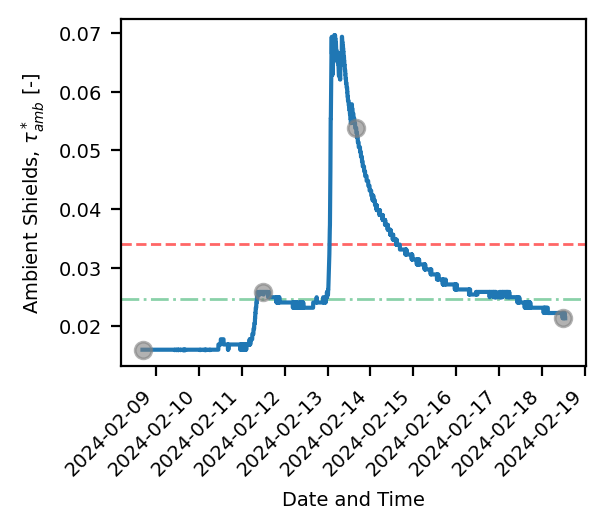

max shields stress from Rh, tau_st =  0.0696316781907257
max shields stress time =  2024-02-13 04:11:54
depth:


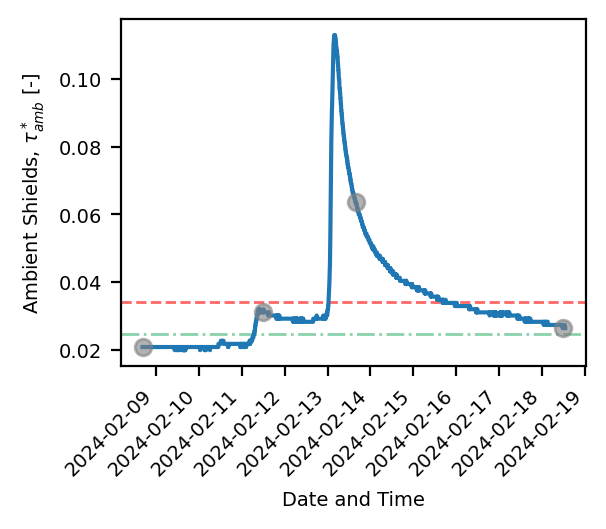

In [5]:
# User input ---------------------------------------------
nest_num = '1' # '1', '2', '3', '4', '5and6'
# -------------------------------------------------------

# Make the output folders
if not os.path.isdir(fig_folder):
    os.mkdir(fig_folder)

nest_name = 'SynthNest'+nest_num
folderpath_HOBOdata = filepath_main

# critical Shields stress thresholds from stress analysis:
tau_st_cr_a_brownlie =  0.03401074441550105
tau_st_cr_a_recking =  0.024734146341463415

if nest_num == '1':
    filename_start = '20240208_20240218'
elif nest_num == '2':
    filename_start = '20240218_20240312'
elif nest_num == '3':
    filename_start = '20240312_20240410'
elif nest_num == '4':
    filename_start = '20241218_20250201'
elif nest_num == '5and6':
    filename_start = '20250201_20250310'
else:
    print('Nest identification not valid.')

hobo_plot_df = pd.read_csv(os.path.join(folderpath_HOBOdata, filename_start+'_HOBOdata_finalPlot.csv'), sep=',')
checktimes_plot_df = pd.read_csv(os.path.join(folderpath_HOBOdata, filename_start+'_HOBOchecks_finalPlot.csv'), sep=',')
# save date-time column name, may differ based on EST or EDT
hobo_datetime_col = [col for col in hobo_plot_df.columns if "Date-Time" in col][0]
# convert to datetime dtype
hobo_plot_df[hobo_datetime_col] = pd.to_datetime(hobo_plot_df[hobo_datetime_col])
checktimes_plot_df[hobo_datetime_col] = pd.to_datetime(checktimes_plot_df[hobo_datetime_col])

# -----------------------------------------
# Plot time series of shear and Shields stress - hydraulic radius 
# ----------------------------------------
print('hydraulic radius:')
ax = plot_stress_timeseries(hobo_plot_df, checktimes_plot_df, hobo_datetime_col, 'tau_st_Rh',
                            nest_name, '_taust_a_Rh_timeseries_noLamb_noLegend.pdf')
plt.close()
print('max shields stress from Rh, tau_st = ', max(hobo_plot_df['tau_st_Rh']))
print('max shields stress time = ', hobo_plot_df.loc[hobo_plot_df['tau_st_Rh'].idxmax(), hobo_datetime_col])

# ---------------------------------------------
# Plot time series of shear and Shields stress - depth
# -----------------------------------------
print('depth:')
ax = plot_stress_timeseries(hobo_plot_df, checktimes_plot_df, hobo_datetime_col, 'tau_st_h',
                            nest_name, '_taust_a_h_timeseries_noLamb_noLegend.pdf')

# -----------------------------------------
# Save legend as standalone PDF
# --------------------------------------
save_legend(ax, nest_name)
plt.close()